In [ ]:
import os
import pickle
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pylab import rcParams
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import warnings
import datetime as dt
import yfinance as yf

# Keras / TensorFlow imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

rcParams['figure.figsize'] = 12,6
warnings.filterwarnings('ignore')

# Chọn mã cổ phiếu phù hợp với tên notebook
bank_stock_name = "VPB.VN"

# Thư mục lưu model
model_dir = os.path.join(os.getcwd(),  'Save_model_LSTM')
stock_model_dir = os.path.join(model_dir, bank_stock_name)
print('Model dir:', stock_model_dir)
if not os.path.exists(stock_model_dir):
    os.makedirs(stock_model_dir, exist_ok=True)


Model dir: d:\Admin\Documents\CuoiKi\PTDL\Big_data_cuoi_ky\Save_model_LSTM\VCB.VN


In [65]:
stock = pd.read_csv(f'data/{bank_stock_name}.csv')
stock.head()

,Date,Close,High,Low,Open,Volume
0,2020-12-21,43580.878906,43624.947859,42875.829949,43580.878906,1660453
1,2020-12-22,43140.226562,43228.356717,42963.962375,43184.291640,1842508
2,2020-12-23,42963.960938,43404.619453,42699.570482,42963.960938,1501307
3,2020-12-24,42875.832031,43140.226373,42302.978271,43140.226373,2189207
4,2020-12-25,43008.031250,43008.031250,42611.437798,42743.636908,865020


# Xây dựng mô hình LSTM

In [66]:
# 1. Chuyển đổi cột Date sang dạng datetime (Quan trọng!)
stock['Date'] = pd.to_datetime(stock['Date'])

# 2. Set index là Date
stock.index = stock['Date']

# 3. Sắp xếp lại dữ liệu theo thời gian (Thêm inplace=True để lưu thay đổi)
stock.sort_index(ascending=True, axis=0, inplace=True)

# Kiểm tra lại
print(stock.head())

                 Date         Close          High           Low          Open  \
Date                                                                            
2020-12-21 2020-12-21  43580.878906  43624.947859  42875.829949  43580.878906   
2020-12-22 2020-12-22  43140.226562  43228.356717  42963.962375  43184.291640   
2020-12-23 2020-12-23  42963.960938  43404.619453  42699.570482  42963.960938   
2020-12-24 2020-12-24  42875.832031  43140.226373  42302.978271  43140.226373   
2020-12-25 2020-12-25  43008.031250  43008.031250  42611.437798  42743.636908   

             Volume  
Date                 
2020-12-21  1660453  
2020-12-22  1842508  
2020-12-23  1501307  
2020-12-24  2189207  
2020-12-25   865020  


In [67]:
# --- CẤU HÌNH QUAN TRỌNG ---
# Dashboard đang để time_step = 60, nên ở đây PHẢI là 60 để khớp lệnh.
PAST_RANGE = 60

# Tạo dataframe mới chỉ chứa cột Close (Cách nhanh, không dùng vòng for)
stock_lstm = stock[['Close']].copy()

# Kiểm tra dữ liệu
print("Đã chọn time_step (PAST_RANGE):", PAST_RANGE)
print(stock_lstm.head())
print(stock_lstm.tail())

Đã chọn time_step (PAST_RANGE): 60
                   Close
Date                    
2020-12-21  43580.878906
2020-12-22  43140.226562
2020-12-23  42963.960938
2020-12-24  42875.832031
2020-12-25  43008.031250
              Close
Date               
2025-12-15  56800.0
2025-12-16  56900.0
2025-12-17  56700.0
2025-12-18  56800.0
2025-12-19  57500.0


In [68]:
# Chuyển đổi về mảng numpy
dataset = stock_lstm.values

# Tính toán vị trí cắt (lấy 80% dữ liệu để train)
training_data_len = int(len(dataset) * 0.8)

# Chia dữ liệu
train = dataset[0:training_data_len, :]
valid = dataset[training_data_len:, :]

print(f"Tổng số dòng: {len(dataset)}")
print(f"Số dòng Train: {len(train)}")
print(f"Số dòng Test (Valid): {len(valid)}")

Tổng số dòng: 1248
Số dòng Train: 998
Số dòng Test (Valid): 250


In [69]:
# Import thư viện để lưu file
import joblib

# 1. Khởi tạo và Fit Scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Scale toàn bộ dữ liệu về khoảng [0, 1]
scaled_data = scaler.fit_transform(dataset)

# --- BẮT BUỘC: LƯU SCALER ---
# Dashboard cần file này để inverse_transform (đổi số về giá tiền)
scaler_path = os.path.join(stock_model_dir, "lstm.pkl")
joblib.dump(scaler, scaler_path)
print(f"✅ Đã lưu Scaler thành công tại: {scaler_path}")

# 2. Tạo dữ liệu train (X_train, y_train) theo cửa sổ trượt (Time Step)
x_train, y_train = [], []

# Lưu ý: len(train) ở đây là số dòng của tập training đã chia ở cell trước
for i in range(PAST_RANGE, len(train)):
    # Lấy PAST_RANGE ngày quá khứ làm đầu vào
    x_train.append(scaled_data[i-PAST_RANGE:i, 0])
    # Lấy ngày hiện tại làm nhãn (target)
    y_train.append(scaled_data[i, 0])

# 3. Chuyển sang numpy array và Reshape cho LSTM
x_train, y_train = np.array(x_train), np.array(y_train)

# Input của LSTM cần shape 3 chiều: (Samples, Time Steps, Features)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print(f"Kích thước x_train: {x_train.shape}")
print(f"Kích thước y_train: {y_train.shape}")

✅ Đã lưu Scaler thành công tại: d:\Admin\Documents\CuoiKi\PTDL\Big_data_cuoi_ky\Save_model_LSTM\VCB.VN\lstm.pkl
Kích thước x_train: (938, 60, 1)
Kích thước y_train: (938,)


Bắt đầu training...
Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0457
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0038
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0023
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0022
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0022
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0021
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0020
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0019
Epoch 9/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0019
Epoch 10/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0021
✅ Training hoàn tất!
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

--- KẾT QUẢ ĐÁNH GIÁ ---
RMSE: 1710.37
MAE: 1085.50
R2: 0.6911



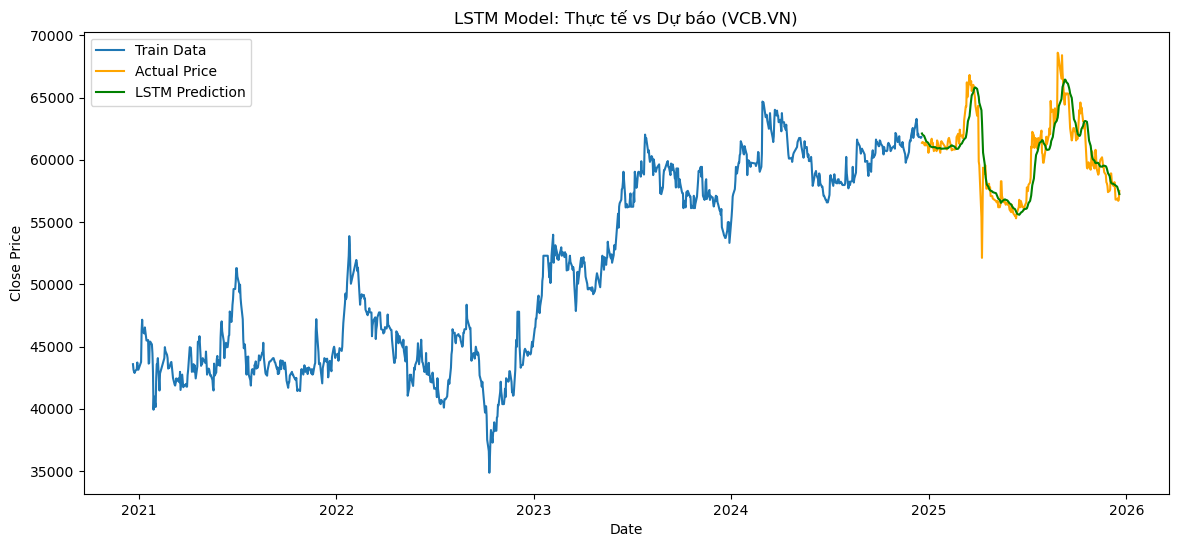

✅ Đã lưu dữ liệu biểu đồ tại: d:\Admin\Documents\CuoiKi\PTDL\Big_data_cuoi_ky\Save_model_LSTM\VCB.VN\lstm.csv

✅ Đã lưu đầy đủ Model, Metrics và Scaler vào: d:\Admin\Documents\CuoiKi\PTDL\Big_data_cuoi_ky\Save_model_LSTM\VCB.VN


In [70]:
# --- XÂY DỰNG VÀ TRAIN MODEL ---
model = Sequential()
# Input shape: (Time Steps, Features)
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(units=50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

# Tăng epochs lên 10-50 để model học tốt hơn (epochs=1 là quá ít)
# Batch_size=32 hoặc 64 giúp train nhanh hơn và ổn định hơn batch_size=1
print("Bắt đầu training...")
model.fit(x_train, y_train, epochs=10, batch_size=32, verbose=1)
print('✅ Training hoàn tất!')

# --- DỰ BÁO TRÊN TẬP TEST (VALIDATION) ---
# Lấy dữ liệu validation cộng thêm khoảng đệm quá khứ (PAST_RANGE)
inputs = stock_lstm[len(stock_lstm) - len(valid) - PAST_RANGE:].values
inputs = inputs.reshape(-1, 1)
inputs = scaler.transform(inputs)

X_test = []
for i in range(PAST_RANGE, inputs.shape[0]):
    X_test.append(inputs[i-PAST_RANGE:i, 0])
X_test = np.array(X_test)

# Reshape cho LSTM
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Dự báo
closing_price = model.predict(X_test)
preds = scaler.inverse_transform(closing_price)

# --- ĐÁNH GIÁ METRICS ---
# y_valid lấy từ dữ liệu gốc (chưa scale) của phần valid
# Lưu ý: valid ban đầu lấy từ .values nên là mảng 2 chiều, cần lấy cột 0
y_valid = valid[:, 0]

mse = mean_squared_error(y_valid, preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_valid, preds)
r2 = r2_score(y_valid, preds)

print(f'\n--- KẾT QUẢ ĐÁNH GIÁ ---')
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R2: {r2:.4f}\n')

# --- VẼ BIỂU ĐỒ (QUAN TRỌNG: SỬA LỖI 990) ---
# Dùng biến training_data_len từ Cell 6 để cắt đúng vị trí
train_df = stock_lstm[:training_data_len]
valid_df = stock_lstm[training_data_len:].copy()

# Gán dự báo vào DataFrame
valid_df['Predictions'] = preds

plt.figure(figsize=(14, 6))
plt.plot(train_df['Close'], label='Train Data')
plt.plot(valid_df['Close'], label='Actual Price', color='orange')
plt.plot(valid_df['Predictions'], label='LSTM Prediction', color='green')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title(f'LSTM Model: Thực tế vs Dự báo ({bank_stock_name})')
plt.legend()
plt.show()

# Tạo DataFrame chứa kết quả so sánh để Dashboard đọc
result_df = valid_df.copy()
# Cột Date đang là index, ta reset để nó thành cột bình thường cho dễ lưu
result_df.reset_index(inplace=True) 
result_df.columns = ['Date', 'Actual', 'Prediction'] # Đặt tên lại cho chuẩn

# Lưu ra file CSV
result_csv_path = os.path.join(stock_model_dir, "lstm.csv")
result_df.to_csv(result_csv_path, index=False)
print(f"✅ Đã lưu dữ liệu biểu đồ tại: {result_csv_path}")

# --- LƯU MODEL & METRICS ---
# 1. Lưu file model .h5
model.save(os.path.join(stock_model_dir, "lstm.h5"))

# 2. Lưu file metrics .json
metrics = {
    "rmse": rmse,
    "mae": mae,
    "r2": r2
}
with open(os.path.join(stock_model_dir, "lstm.json"), 'w') as f:
    json.dump(metrics, f)

# 3. Lưu Scaler (Dùng joblib cho đồng bộ với Dashboard)
import joblib
scaler_path = os.path.join(stock_model_dir, "lstm.pkl")
joblib.dump(scaler, scaler_path)

print(f'\n✅ Đã lưu đầy đủ Model, Metrics và Scaler vào: {stock_model_dir}')